# Setup

In [ ]:
# standard library imports
import time

# third party library imports
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd

# machine learning imports
from catboost import CatBoostRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    AdaBoostRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    make_scorer,
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
    root_mean_squared_log_error,
)
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    RobustScaler,
    TargetEncoder,
)
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

# local imports
from utils import (
    adversarial_score,
    barplot,
    countplot,
    heatmap,
    histplot,
    kdeplot,
    lineplot,
    scatterplot,
    subplots,
)

In [2]:
# patch sklearn for performance boost
from sklearnex import patch_sklearn

patch_sklearn(verbose=False)

# EDA

In [3]:
# load data
index_col = "id"
train_data = pd.read_csv("train.csv", index_col=index_col)
test_data = pd.read_csv("test.csv", index_col=index_col)
sub_data = pd.read_csv("sample_submission.csv", index_col=index_col)

In [4]:
# preview data
train_data

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
id,,,,,,,,,,,,,,,,,,,,,
0,5,8,5,8,6,4,4,3,3,4,...,5,3,3,5,4,7,5,7,3,0.445
1,6,7,4,4,8,8,3,5,4,6,...,7,2,0,3,5,3,3,4,3,0.450
2,6,5,6,7,3,7,1,5,4,5,...,7,3,7,5,6,8,2,3,3,0.530
3,3,4,6,5,4,8,4,7,6,8,...,2,4,7,4,4,6,5,7,5,0.535
4,5,3,2,6,4,4,3,3,3,3,...,2,2,6,6,4,1,2,3,5,0.415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1117952,3,3,4,10,4,5,5,7,10,4,...,7,8,7,2,2,1,4,6,4,0.495
1117953,2,2,4,3,9,5,8,1,3,5,...,9,4,4,3,7,4,9,4,5,0.480
1117954,7,3,9,4,6,5,9,1,3,4,...,5,5,5,5,6,5,5,2,4,0.485


In [5]:
# check data types
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1117957 entries, 0 to 1117956
Data columns (total 21 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   MonsoonIntensity                 1117957 non-null  int64  
 1   TopographyDrainage               1117957 non-null  int64  
 2   RiverManagement                  1117957 non-null  int64  
 3   Deforestation                    1117957 non-null  int64  
 4   Urbanization                     1117957 non-null  int64  
 5   ClimateChange                    1117957 non-null  int64  
 6   DamsQuality                      1117957 non-null  int64  
 7   Siltation                        1117957 non-null  int64  
 8   AgriculturalPractices            1117957 non-null  int64  
 9   Encroachments                    1117957 non-null  int64  
 10  IneffectiveDisasterPreparedness  1117957 non-null  int64  
 11  DrainageSystems                  1117957 non-null  int64  
 1

In [6]:
# check for missing values in each column
train_data.isna().sum().sort_values(ascending=False)

MonsoonIntensity                   0
TopographyDrainage                 0
RiverManagement                    0
Deforestation                      0
Urbanization                       0
ClimateChange                      0
DamsQuality                        0
Siltation                          0
AgriculturalPractices              0
Encroachments                      0
IneffectiveDisasterPreparedness    0
DrainageSystems                    0
CoastalVulnerability               0
Landslides                         0
Watersheds                         0
DeterioratingInfrastructure        0
PopulationScore                    0
WetlandLoss                        0
InadequatePlanning                 0
PoliticalFactors                   0
FloodProbability                   0
dtype: int64

In [7]:
# check for unique values
train_data.nunique()

MonsoonIntensity                   17
TopographyDrainage                 19
RiverManagement                    17
Deforestation                      18
Urbanization                       18
ClimateChange                      18
DamsQuality                        17
Siltation                          17
AgriculturalPractices              17
Encroachments                      19
IneffectiveDisasterPreparedness    17
DrainageSystems                    18
CoastalVulnerability               18
Landslides                         17
Watersheds                         17
DeterioratingInfrastructure        18
PopulationScore                    19
WetlandLoss                        20
InadequatePlanning                 17
PoliticalFactors                   17
FloodProbability                   83
dtype: int64

count    1.118e+06
mean     5.045e-01
std      5.103e-02
min      2.850e-01
25%      4.700e-01
50%      5.050e-01
75%      5.400e-01
max      7.250e-01
Name: FloodProbability, dtype: float64

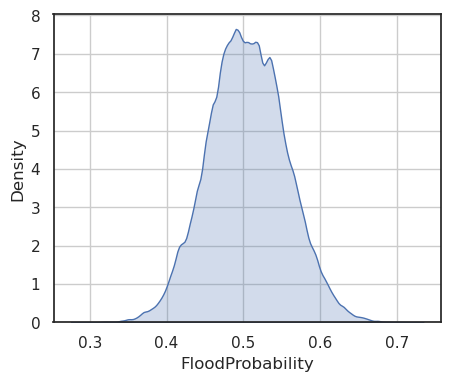

In [8]:
# set target
target = "FloodProbability"
ax = kdeplot(x=train_data[target])
train_data[target].describe()

In [ ]:
# process data
def process_data(df: pd.DataFrame):
    new_df = df.copy()

    features = [col for col in new_df.columns if col != target]

    new_df["SumOfFeatures"] = new_df[features].sum(axis=1)  # for tree models
    new_df["IsSumBetween72And75"] = (
        new_df["SumOfFeatures"].isin(np.arange(72, 76)).astype(int)
    )  # for linear models

    return new_df


train_data = process_data(train_data)
test_data = process_data(test_data)

In [ ]:
# set features
numerical_features = [
    "AgriculturalPractices",
    "ClimateChange",
    "CoastalVulnerability",
    "DamsQuality",
    "Deforestation",
    "DeterioratingInfrastructure",
    "DrainageSystems",
    "Encroachments",
    "InadequatePlanning",
    "IneffectiveDisasterPreparedness",
    "Landslides",
    "MonsoonIntensity",
    "PoliticalFactors",
    "PopulationScore",
    "RiverManagement",
    "Siltation",
    "SumOfFeatures",  # feature engineered
    "TopographyDrainage",
    "Urbanization",
    "Watersheds",
    "WetlandLoss",
]
ordinal_features = [
    "IsSumBetween72And75",  # feature engineered
]
ordinal_categories = [
    [0, 1],  # IsSumBetween72And75
]

categorical_features = ordinal_features
features = numerical_features + categorical_features

plot_features = sorted(numerical_features + categorical_features)
corr_features = [target] + sorted(numerical_features + ordinal_features)

In [11]:
# use copies for exploratory analysis
train_data_encoded = train_data.copy()
test_data_encoded = test_data.copy()

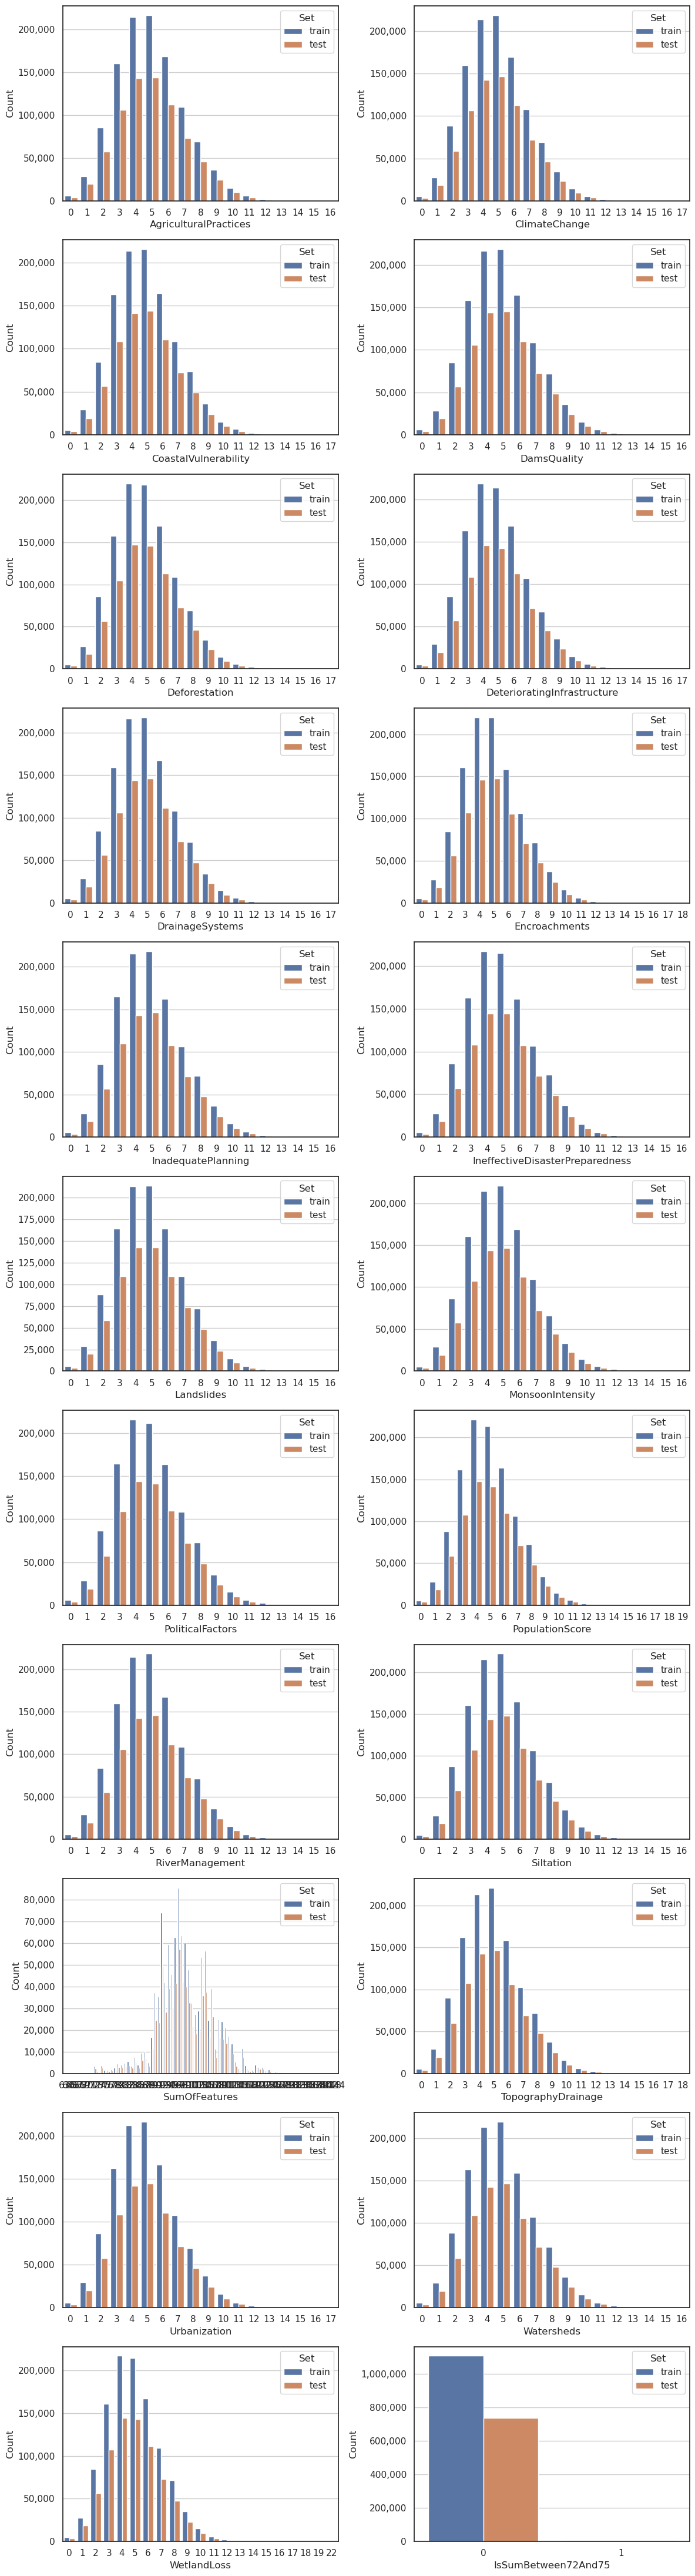

In [12]:
# plot features
unmerged_data = [train_data.assign(Set="train"), test_data.assign(Set="test")]
merged_data = pd.concat(unmerged_data, ignore_index=True, join="inner")
feature_groups = [(numerical_features, countplot), (categorical_features, countplot)]
fig, axes = subplots(feature_groups, data=merged_data, hue="Set")

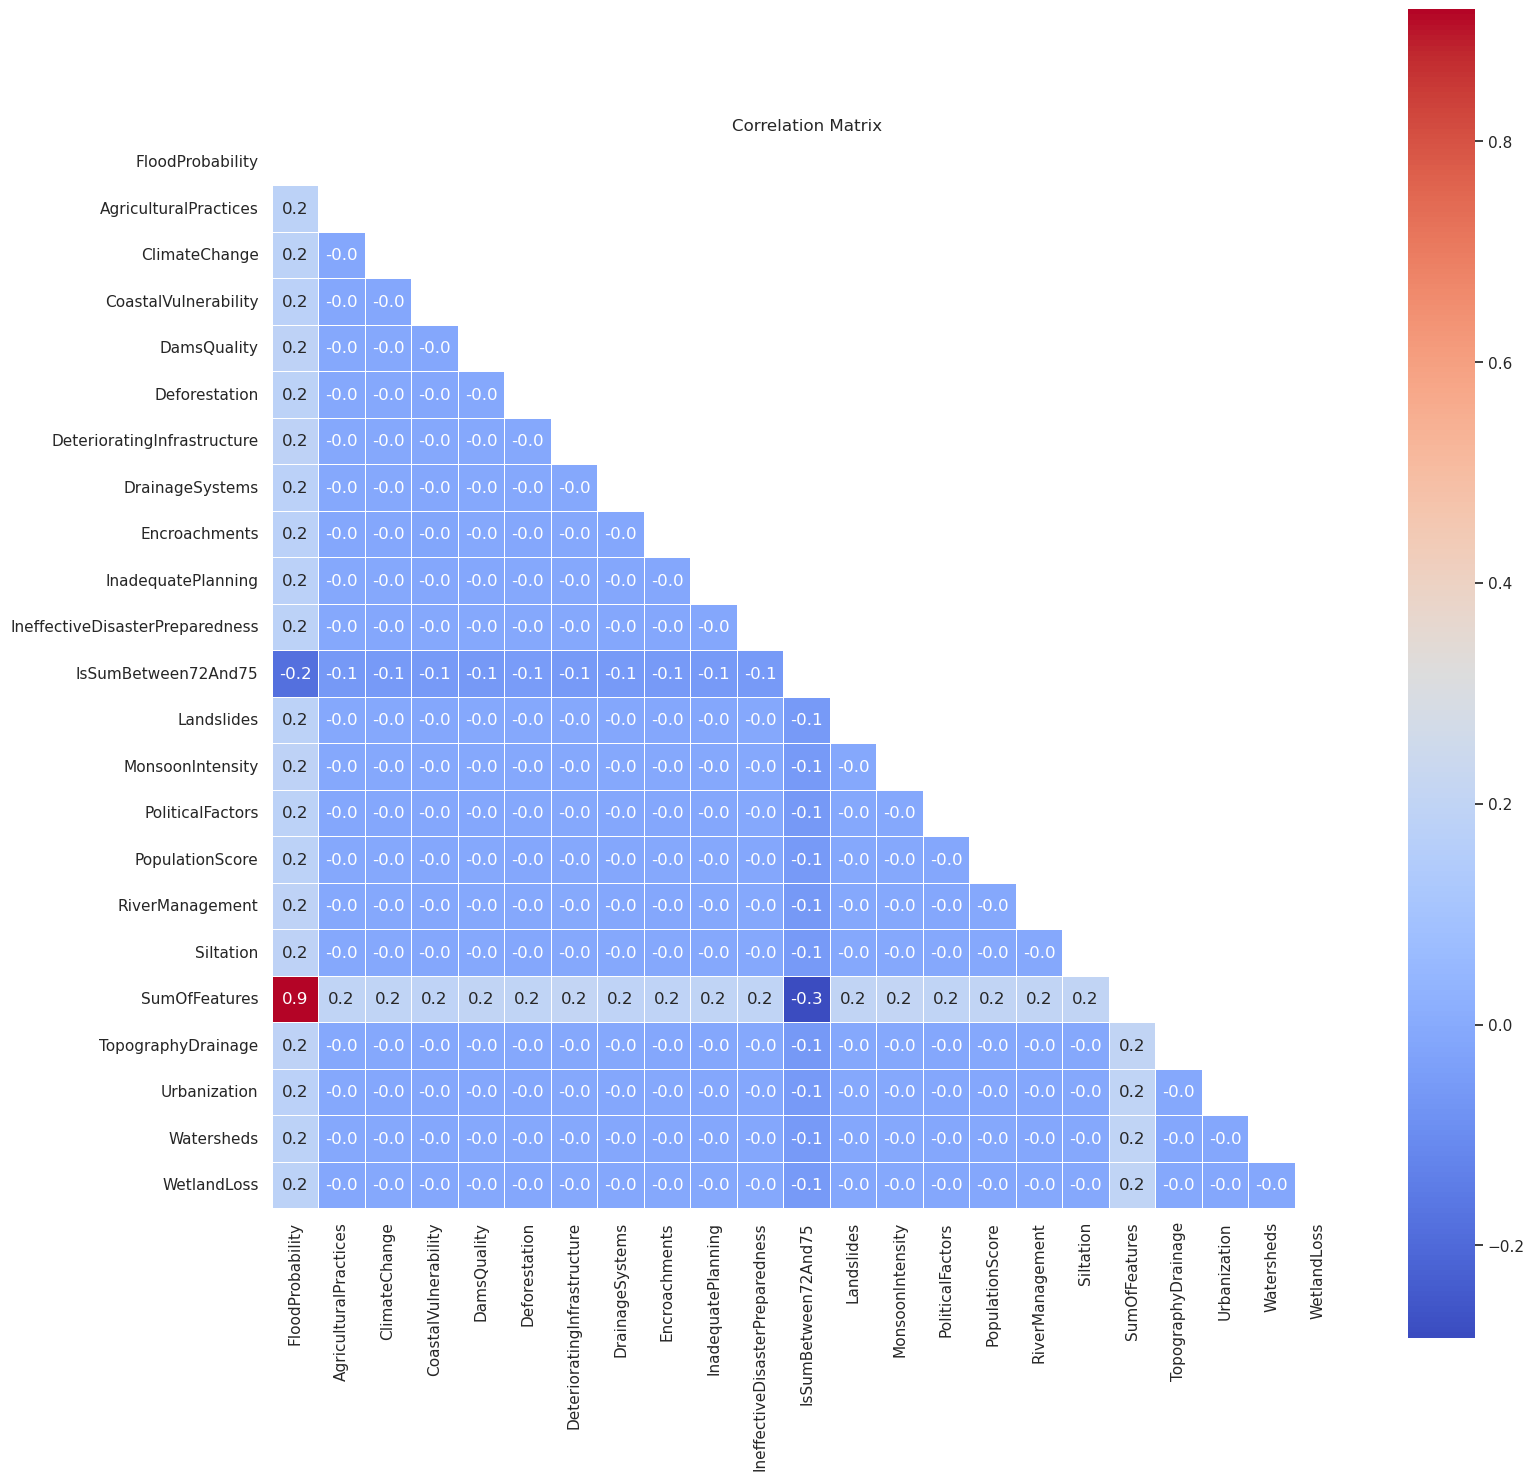

In [13]:
# plot correlations
corr = train_data_encoded[corr_features].corr()
ax = heatmap(data=corr, mask=np.triu(corr))
_ = ax.set_title("Correlation Matrix")

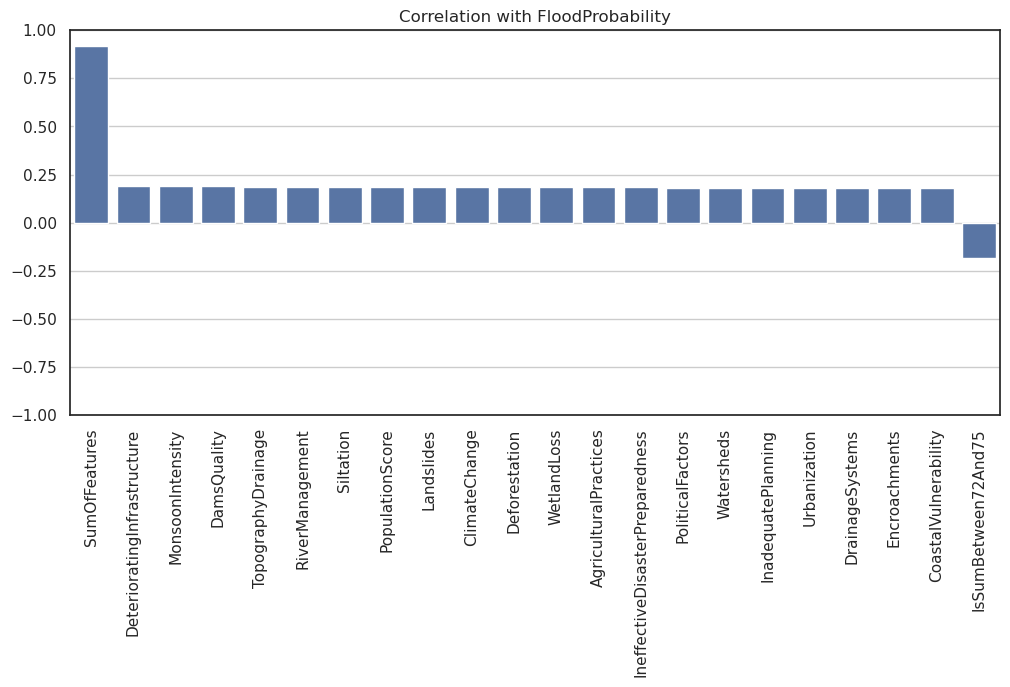

In [14]:
# plot target correlations
corrwith = corr[target].drop(target).sort_values(ascending=False)

ax = barplot(x=corrwith.index, y=corrwith.to_numpy(), rotation=90)
_ = ax.set_xlabel("")
_ = ax.set_ylim(-1, 1)
_ = ax.set_title(f"Correlation with {target}")

In [15]:
# validate that train and test sets have similar distributions
score = adversarial_score(data=merged_data, model=LGBMClassifier(verbose=-1))

threshold = 0.6
comp = "<" if score < threshold else ">="
message = "indistinguishable" if score < threshold else "distinguishable"
print(f"Score = {score:.2f} {comp} threshold = {threshold} → distributions {message}")

Score = 0.50 < threshold = 0.6 → distributions indistinguishable


# Data Preprocessing

In [16]:
# split data into training and test sets
X = train_data[features]
y = train_data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# define preprocessing columns and steps
transformer_config = {
    "numerical": {
        "columns": numerical_features,
        "steps": [
            (
                "scale",
                RobustScaler(),
            ),
        ],
    },
    "ordinal": {
        "columns": ordinal_features,
        "steps": [
            (
                "encode",
                OrdinalEncoder(
                    categories=ordinal_categories,
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                ),
            ),
        ],
    },
}

In [18]:
# build preprocessor
transformers = []
for feature_type, config in transformer_config.items():
    columns = config["columns"]
    steps = config["steps"]
    feature_pipeline = Pipeline(steps=steps)
    transformers.append((feature_type, feature_pipeline, columns))

preprocessor = ColumnTransformer(transformers=transformers)
preprocessor.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('ordinal', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name

In [19]:
# define scoring metrics
metrics = {
    "r2": {
        "func": r2_score,
    },
    "neg_mae": {
        "func": lambda y_true, y_pred: -mean_absolute_error(y_true, y_pred),
    },
    "neg_rmse": {
        "func": lambda y_true, y_pred: -root_mean_squared_error(y_true, y_pred),
    },
    "neg_rmsle": {
        "func": lambda y_true, y_pred: (
            -root_mean_squared_log_error(y_true, np.maximum(y_pred, 0))
        ),
    },
}

primary_metric = "r2"
primary_scorer = make_scorer(metrics[primary_metric]["func"])

# Modelling

In [20]:
# create models and parameter spaces
models = {
    "ridge": {
        "model": Ridge(),
        "params": {
            "ridge__alpha": ("float", 1e-3, 1e3, {"log": True}),
        },
    },
    # too slow
    # "svr": {
    #     "model": SVR(),
    #     "params": {
    #         "svr__C": ("float", 1e-3, 1e3, {"log": True}),
    #         "svr__kernel": ("categorical", ["linear", "rbf", "poly"], None, {}),
    #         "svr__gamma": ("float", 1e-4, 1e0, {"log": True}),
    #         "svr__epsilon": ("float", 1e-3, 1.0, {"log": True}),
    #     },
    # },
    # too slow
    # "rf": {
    #     "model": RandomForestRegressor(random_state=42),
    #     "params": {
    #         "rf__n_estimators": ("int", 50, 500, {}),
    #         "rf__max_depth": ("int", 3, 20, {}),
    #         "rf__min_samples_split": ("int", 2, 20, {}),
    #         "rf__min_samples_leaf": ("int", 1, 10, {}),
    #         "rf__max_features": ("categorical", ["sqrt", "log2"], None, {}),
    #     },
    # },
    "decision": {
        "model": DecisionTreeRegressor(random_state=42),
        "params": {
            "decision__max_depth": ("int", 3, 20, {}),
            "decision__min_samples_split": ("int", 2, 20, {}),
            "decision__min_samples_leaf": ("int", 1, 10, {}),
            "decision__criterion": (
                "categorical",
                ["squared_error", "absolute_error"],
                None,
                {},
            ),
        },
    },
    "xgb": {
        "model": XGBRegressor(random_state=42, enable_categorical=True),
        "params": {
            "xgb__n_estimators": ("int", 100, 1000, {}),
            "xgb__max_depth": ("int", 3, 10, {}),
            "xgb__learning_rate": ("float", 1e-3, 0.3, {"log": True}),
            "xgb__subsample": ("float", 0.5, 1.0, {}),
            "xgb__colsample_bytree": ("float", 0.5, 1.0, {}),
            "xgb__min_child_weight": ("int", 1, 10, {}),
            "xgb__gamma": ("float", 1e-8, 1.0, {"log": True}),
        },
    },
    "lgb": {
        "model": LGBMRegressor(random_state=42, verbose=-1),
        "params": {
            "lgb__n_estimators": ("int", 100, 1000, {}),
            "lgb__num_leaves": ("int", 31, 128, {}),
            "lgb__learning_rate": ("float", 1e-3, 0.3, {"log": True}),
            "lgb__subsample": ("float", 0.5, 1.0, {}),
            "lgb__colsample_bytree": ("float", 0.5, 1.0, {}),
            "lgb__min_child_samples": ("int", 20, 200, {}),
            "lgb__reg_alpha": ("float", 1e-8, 10.0, {"log": True}),
            "lgb__reg_lambda": ("float", 1e-8, 10.0, {"log": True}),
        },
    },
    # too slow
    # "gb": {
    #     "model": GradientBoostingRegressor(random_state=42),
    #     "params": {
    #         "gb__n_estimators": ("int", 50, 500, {}),
    #         "gb__learning_rate": ("float", 1e-3, 0.3, {"log": True}),
    #         "gb__max_depth": ("int", 3, 10, {}),
    #         "gb__subsample": ("float", 0.5, 1.0, {}),
    #         "gb__min_samples_split": ("int", 2, 20, {}),
    #         "gb__min_samples_leaf": ("int", 1, 10, {}),
    #     },
    # },
    # too slow
    # "ada": {
    #     "model": AdaBoostRegressor(random_state=42),
    #     "params": {
    #         "ada__n_estimators": ("int", 50, 500, {}),
    #         "ada__learning_rate": ("float", 1e-3, 1.0, {"log": True}),
    #     },
    # },
    "cat": {
        "model": CatBoostRegressor(
            random_state=42,
            verbose=0,
            bootstrap_type="Bernoulli",
            allow_writing_files=False,
        ),
        "params": {
            "cat__iterations": ("int", 100, 1000, {}),
            "cat__depth": ("int", 3, 10, {}),
            "cat__learning_rate": ("float", 1e-3, 0.3, {"log": True}),
            "cat__l2_leaf_reg": ("float", 1e-3, 10.0, {"log": True}),
            "cat__subsample": ("float", 0.5, 1.0, {}),
        },
    },
}

In [21]:
# train all models with default parameters on X_train
train_results_list = []
train_times = {}
pipelines = {}

cv_train = KFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model_config in models.items():
    pipeline = Pipeline(
        [
            ("preprocessor", preprocessor),
            (model_name, model_config["model"]),
        ]
    )

    start_time = time.time()
    search = GridSearchCV(
        estimator=pipeline,
        param_grid={},
        cv=cv_train,
        scoring=primary_scorer,
        refit=True,
    )
    search.fit(X_train, y_train)
    elapsed_time = time.time() - start_time

    cv_scores = {primary_metric: search.cv_results_["mean_test_score"][0]}
    cv_scores["model"] = model_name

    pipelines[model_name] = search.best_estimator_
    train_times[model_name] = elapsed_time
    train_results_list.append(cv_scores)

train_results = pd.DataFrame(train_results_list).set_index("model")
train_results = train_results.sort_values(primary_metric, ascending=False)
best_model_name = str(train_results[primary_metric].idxmax())
display(train_results)

,r2
model,
cat,0.867
lgb,0.867
xgb,0.867
ridge,0.851
decision,0.726


In [22]:
# define objective function for tuning
def make_objective(model_name, cv, metric):
    def objective(trial):
        param_space = models[model_name]["params"]
        params = {}
        for param_name, spec in param_space.items():
            suggest_type, low, high, kwargs = spec
            if suggest_type == "int":
                params[param_name] = trial.suggest_int(param_name, low, high, **kwargs)
            elif suggest_type == "float":
                params[param_name] = trial.suggest_float(
                    param_name, low, high, **kwargs
                )
            elif suggest_type == "categorical":
                params[param_name] = trial.suggest_categorical(param_name, low)

        trial_pipeline = clone(pipelines[model_name])
        trial_pipeline.set_params(**params)

        scores = []
        for train_idx, val_idx in cv.split(X_train):
            X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            trial_pipeline.fit(X_fold_train, y_fold_train)
            y_fold_pred = trial_pipeline.predict(X_fold_val)
            scores.append(metrics[metric]["func"](y_fold_val, y_fold_pred))

        return sum(scores) / len(scores)

    return objective

In [23]:
# tune best model on X_train
cv_tune = KFold(n_splits=5, shuffle=True, random_state=42)

tuned_start_time = time.time()

study = optuna.create_study(
    direction="maximize", sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(
    make_objective(best_model_name, cv_tune, primary_metric),
    n_trials=20,
    show_progress_bar=True,
)

tuned_elapsed_time = time.time() - tuned_start_time

tuned_model_name = f"{best_model_name}_tuned"
tuned_params = study.best_params

tuned_pipeline = clone(pipelines[best_model_name])
tuned_pipeline.set_params(**tuned_params)
tuned_pipeline.fit(X_train, y_train)

pipelines[tuned_model_name] = tuned_pipeline
train_times[tuned_model_name] = tuned_elapsed_time

tune_results = train_results.loc[[best_model_name]].copy()
tune_results.loc[tuned_model_name] = {primary_metric: study.best_value}
tune_results = tune_results.sort_values(primary_metric, ascending=False)
display(tune_results)
display(tuned_params)

Best trial: 18. Best value: 0.86728: 100%|██████████| 20/20 [30:25<00:00, 91.29s/it]  


,r2
model,
cat,0.867
cat_tuned,0.867


{'cat__iterations': 513,
 'cat__depth': 7,
 'cat__learning_rate': 0.11097099466719954,
 'cat__l2_leaf_reg': 1.4572030694251614,
 'cat__subsample': 0.9181766491817129}

In [24]:
# evaluate all models on X_test
test_results_list = []

for model_name, pipeline in pipelines.items():
    y_test_pred = pipeline.predict(X_test)

    test_scores = {}
    for metric_name, metric_config in metrics.items():
        test_scores[metric_name] = metric_config["func"](y_test, y_test_pred)

    test_scores["model"] = model_name
    test_results_list.append(test_scores)

test_results = pd.DataFrame(test_results_list).set_index("model")
test_results["train_time"] = pd.Series(train_times)
test_results = test_results.sort_values(primary_metric, ascending=False)

display(test_results)

,r2,neg_mae,neg_rmse,neg_rmsle,train_time
model,,,,,
cat,0.867,-0.014,-0.019,-0.012,158.672
cat_tuned,0.867,-0.015,-0.019,-0.012,1825.759
lgb,0.867,-0.015,-0.019,-0.012,17.151
xgb,0.867,-0.014,-0.019,-0.012,15.468
ridge,0.851,-0.015,-0.020,-0.013,3.410
decision,0.726,-0.019,-0.027,-0.018,68.421


In [25]:
# retrain tuned model on X_train and X_test
final_model = clone(tuned_pipeline)
final_model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('cat', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('ordinal', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

# Results

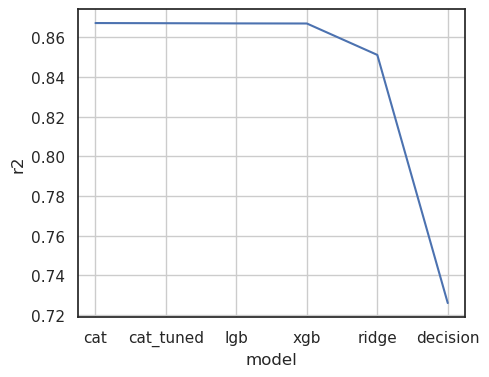

In [26]:
# plot initial results
ax = lineplot(data=test_results.reset_index(), x="model", y=primary_metric)

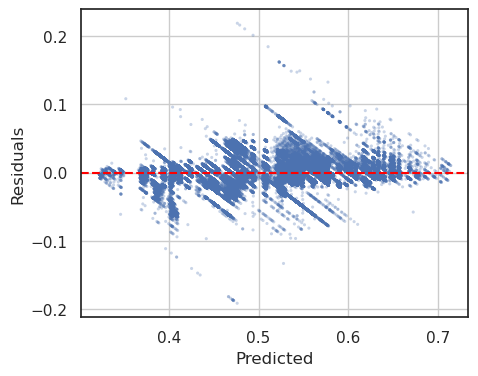

In [27]:
# plot residuals
y_pred = final_model.predict(X)
residuals = y.values - y_pred

ax = scatterplot(x=y_pred, y=residuals, alpha=0.3, s=5, edgecolor="none")
_ = ax.axhline(0, color="red", linestyle="--")
_ = ax.set_xlabel("Predicted")
_ = ax.set_ylabel("Residuals")

In [28]:
# make predictions
test_pred = final_model.predict(test_data)

# write to submissions file
sub_data[target] = test_pred
sub_data.to_csv("submission.csv", index=True, index_label=index_col)

pd.read_csv("submission.csv")

,id,FloodProbability
0,1117957,0.577
1,1117958,0.451
2,1117959,0.450
3,1117960,0.471
4,1117961,0.472
...,...,...
745300,1863257,0.476
745301,1863258,0.442
745302,1863259,0.620
745303,1863260,0.549


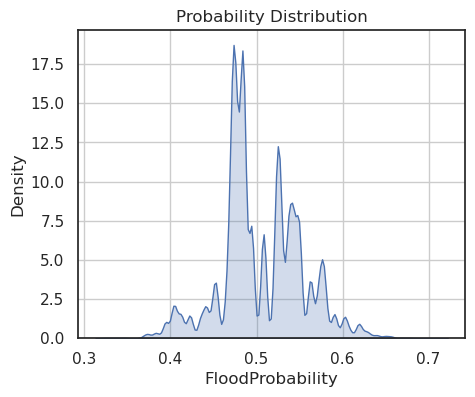

In [29]:
# plot predictions/probabilities
ax = kdeplot(x=sub_data[target])
_ = ax.set_title("Probability Distribution")